In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

In [146]:
import pandas as pd

# Load
flights = pd.read_csv("../data/flights.csv", low_memory=False)
airports = pd.read_csv("../data/airports.csv")
airlines = pd.read_csv("../data/airlines.csv")

# Join airlines (by AIRLINE code)
flights = flights.merge(airlines, left_on="AIRLINE", right_on="IATA_CODE", how="left") \
                 .drop(columns="IATA_CODE") \
                 .rename(columns={"AIRLINE_y": "AIRLINE_NAME", "AIRLINE_x": "AIRLINE"})

# Join airports for ORIGIN
flights = flights.merge(airports, left_on="ORIGIN_AIRPORT", right_on="IATA_CODE", how="left") \
                 .drop(columns="IATA_CODE") \
                 .rename(columns={
                     "AIRPORT": "ORIGIN_AIRPORT_NAME",
                     "CITY": "ORIGIN_CITY",
                     "STATE": "ORIGIN_STATE",
                     "LATITUDE": "ORIGIN_LAT",
                     "LONGITUDE": "ORIGIN_LON"
                 }).drop(columns=["COUNTRY"])

# Join airports for DESTINATION
flights = flights.merge(airports, left_on="DESTINATION_AIRPORT", right_on="IATA_CODE", how="left") \
                 .drop(columns="IATA_CODE") \
                 .rename(columns={
                     "AIRPORT": "DEST_AIRPORT_NAME",
                     "CITY": "DEST_CITY",
                     "STATE": "DEST_STATE",
                     "LATITUDE": "DEST_LAT",
                     "LONGITUDE": "DEST_LON"
                 }).drop(columns=["COUNTRY"])

print(f"Shape: {flights.shape}")
flights.head()

Shape: (5819079, 42)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_LAT,ORIGIN_LON,DEST_AIRPORT_NAME,DEST_CITY,DEST_STATE,DEST_LAT,DEST_LON
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,47.44898,-122.30931
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,26.68316,-80.09559
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US Airways Inc.,San Francisco International Airport,San Francisco,CA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,35.21401,-80.94313
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,Miami International Airport,Miami,FL,25.79325,-80.29056
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,61.17432,-149.99619


# Unique

In [147]:
for col in flights.columns:
    counts = flights[col].value_counts()
    n_unique = flights[col].nunique()
    
    # Skip high-cardinality columns (like flight numbers, tail numbers, times)
    if n_unique > 20:
        print(f"{col}: {n_unique} unique values (skipping...)\n")
        continue
    
    print(f"{col} counts ({n_unique} unique):\n{counts}\n{'-'*40}\n")



YEAR counts (1 unique):
YEAR
2015    5819079
Name: count, dtype: int64
----------------------------------------

MONTH counts (12 unique):
MONTH
7     520718
8     510536
3     504312
6     503897
5     496993
10    486165
4     485151
12    479230
1     469968
11    467972
9     464946
2     429191
Name: count, dtype: int64
----------------------------------------

DAY: 31 unique values (skipping...)

DAY_OF_WEEK counts (7 unique):
DAY_OF_WEEK
4    872521
1    865543
5    862209
3    855897
2    844600
7    817764
6    700545
Name: count, dtype: int64
----------------------------------------

AIRLINE counts (14 unique):
AIRLINE
WN    1261855
DL     875881
AA     725984
OO     588353
EV     571977
UA     515723
MQ     294632
B6     267048
US     198715
AS     172521
NK     117379
F9      90836
HA      76272
VX      61903
Name: count, dtype: int64
----------------------------------------

FLIGHT_NUMBER: 6952 unique values (skipping...)

TAIL_NUMBER: 4897 unique values (skipping...)

ORI

# list values

In [148]:
flights['AIR_SYSTEM_DELAY'].unique()

array([      nan, 2.500e+01, 4.300e+01, 0.000e+00, 2.000e+01, 1.700e+01,
       1.300e+01, 7.000e+00, 2.200e+01, 1.400e+01, 4.000e+00, 6.000e+00,
       1.600e+01, 2.700e+01, 1.200e+01, 2.000e+00, 1.500e+01, 1.800e+01,
       3.200e+01, 8.500e+01, 3.000e+00, 5.000e+00, 8.600e+01, 5.800e+01,
       3.500e+01, 3.400e+01, 3.300e+01, 1.100e+01, 9.000e+00, 2.600e+01,
       2.800e+01, 4.000e+01, 2.300e+01, 1.900e+01, 2.400e+01, 9.700e+01,
       2.900e+01, 2.100e+01, 1.000e+00, 1.000e+01, 8.000e+00, 3.000e+01,
       6.700e+01, 4.800e+01, 6.500e+01, 3.100e+01, 4.100e+01, 4.200e+01,
       3.900e+01, 3.600e+01, 5.100e+01, 8.100e+01, 4.600e+01, 1.640e+02,
       5.200e+01, 8.800e+01, 4.900e+01, 4.500e+01, 3.700e+01, 5.000e+01,
       5.400e+01, 5.900e+01, 1.380e+02, 5.300e+01, 7.200e+01, 6.800e+01,
       7.700e+01, 6.100e+01, 6.000e+01, 4.400e+01, 3.800e+01, 7.600e+01,
       4.700e+01, 7.300e+01, 5.700e+01, 7.400e+01, 8.700e+01, 5.600e+01,
       6.300e+01, 1.350e+02, 1.200e+02, 1.160e+02, 

# Is NaN

In [149]:
missing = pd.DataFrame({
    'count': flights.isna().sum(),
    'percentage': flights.isna().mean() * 100
})

missing[missing['count'] > 0]

,count,percentage
TAIL_NUMBER,14721,0.252978
DEPARTURE_TIME,86153,1.480526
DEPARTURE_DELAY,86153,1.480526
TAXI_OUT,89047,1.530259
WHEELS_OFF,89047,1.530259
SCHEDULED_TIME,6,0.000103
ELAPSED_TIME,105071,1.805629
AIR_TIME,105071,1.805629
WHEELS_ON,92513,1.589822
TAXI_IN,92513,1.589822


In [ ]:
print(f"Shape before filtering: {flights.shape}")

flights = (
    flights
    .drop(columns=["YEAR", "TAIL_NUMBER", "FLIGHT_NUMBER"])
    .query("CANCELLED == 0")
    .drop(columns=['CANCELLED', 'CANCELLATION_REASON'])
)

print(f"Shape after filtering: {flights.shape}")
flights.head(15)

Shape before filtering: (5819079, 42)
Shape after filtering: (5714008, 37)


,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_LAT,ORIGIN_LON,DEST_AIRPORT_NAME,DEST_CITY,DEST_STATE,DEST_LAT,DEST_LON
0,1,1,4,AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,47.44898,-122.30931
1,1,1,4,AA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,26.68316,-80.09559
2,1,1,4,US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0.0,0.0,0.0,0.0,0.0,US Airways Inc.,San Francisco International Airport,San Francisco,CA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,35.21401,-80.94313
3,1,1,4,AA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,Miami International Airport,Miami,FL,25.79325,-80.29056
4,1,1,4,AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,61.17432,-149.99619
5,1,1,4,DL,SFO,MSP,25,20.0,-5.0,18.0,38.0,217.0,230.0,206.0,1589,604.0,6.0,602,610.0,8.0,0,0.0,0.0,0.0,0.0,0.0,Delta Air Lines Inc.,San Francisco International Airport,San Francisco,CA,37.61900,-122.37484,Minneapolis-Saint Paul International Airport,Minneapolis,MN,44.88055,-93.21692
6,1,1,4,NK,LAS,MSP,25,19.0,-6.0,11.0,30.0,181.0,170.0,154.0,1299,504.0,5.0,526,509.0,-17.0,0,0.0,0.0,0.0,0.0,0.0,Spirit Air Lines,McCarran International Airport,Las Vegas,NV,36.08036,-115.15233,Minneapolis-Saint Paul International Airport,Minneapolis,MN,44.88055,-93.21692
7,1,1,4,US,LAX,CLT,30,44.0,14.0,13.0,57.0,273.0,249.0,228.0,2125,745.0,8.0,803,753.0,-10.0,0,0.0,0.0,0.0,0.0,0.0,US Airways Inc.,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,Charlotte Douglas International Airport,Charlotte,NC,35.21401,-80.94313
8,1,1,4,AA,SFO,DFW,30,19.0,-11.0,17.0,36.0,195.0,193.0,173.0,1464,529.0,3.0,545,532.0,-13.0,0,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,San Francisco International Airport,San Francisco,CA,37.61900,-122.37484,Dallas/Fort Worth International Airport,Dallas-Fort Worth,TX,32.89595,-97.03720
9,1,1,4,DL,LAS,ATL,30,33.0,3.0,12.0,45.0,221.0,203.0,186.0,1747,651.0,5.0,711,656.0,-15.0,0,0.0,0.0,0.0,0.0,0.0,Delta Air Lines Inc.,McCarran International Airport,Las Vegas,NV,36.08036,-115.15233,Hartsfield-Jackson Atlanta International Airport,Atlanta,GA,33.64044,-84.42694


## Trains vs test

In [151]:
from sklearn.model_selection import train_test_split

x = flights[["MONTH","DAY","DAY_OF_WEEK","AIRLINE","ORIGIN_AIRPORT","DESTINATION_AIRPORT","SCHEDULED_DEPARTURE","DEPARTURE_TIME","DEPARTURE_DELAY","TAXI_OUT","WHEELS_OFF","SCHEDULED_TIME","ELAPSED_TIME","AIR_TIME","DISTANCE","WHEELS_ON","TAXI_IN","SCHEDULED_ARRIVAL","ARRIVAL_TIME","DIVERTED","CANCELLED","CANCELLATION_REASON","AIR_SYSTEM_DELAY","SECURITY_DELAY","AIRLINE_DELAY","LATE_AIRCRAFT_DELAY","WEATHER_DELAY"]]
y = flights["ARRIVAL_DELAY"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=23)

KeyError: "['CANCELLED', 'CANCELLATION_REASON'] not in index"

## Correlation

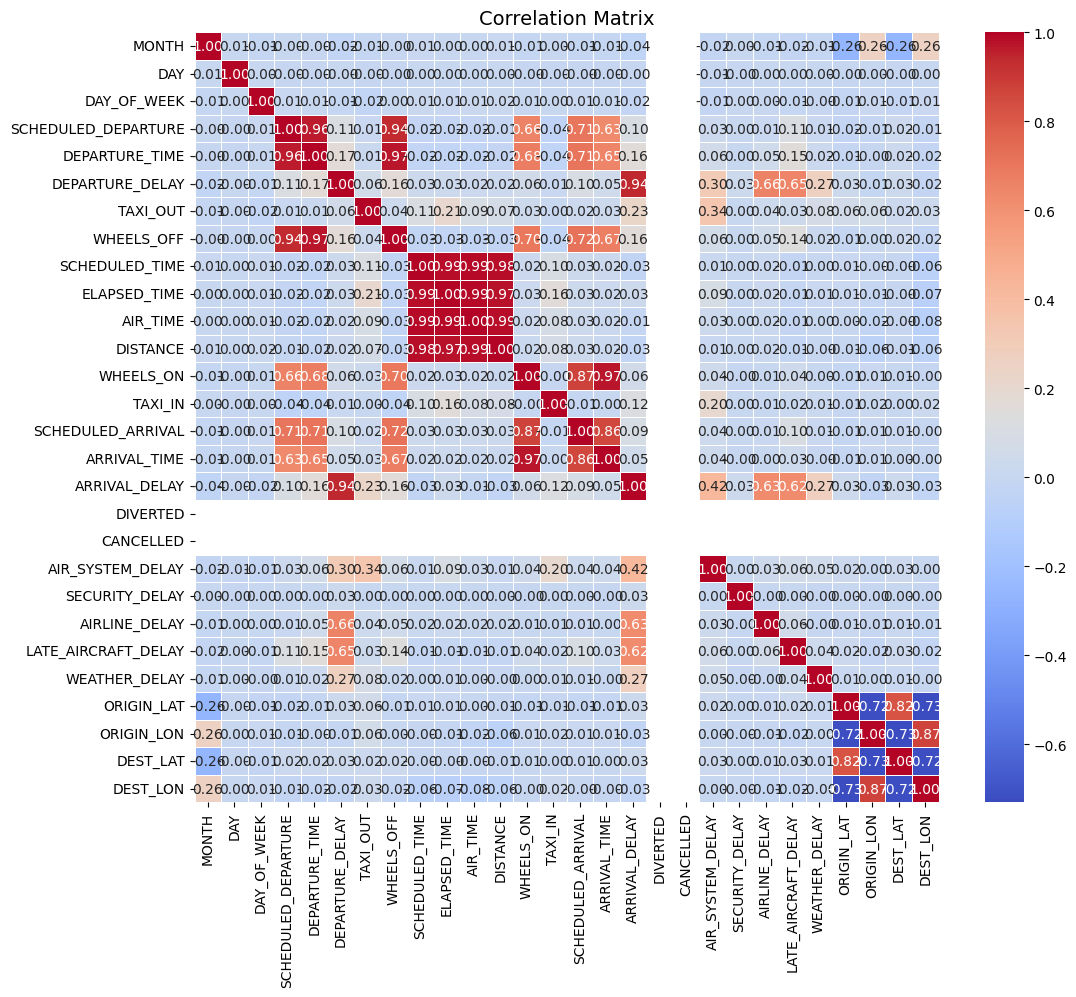

In [ ]:
flights_corr = (
    flights
)

corr = flights_corr.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()